# 1. Eksploracja danych BTC/USDT

Ten notebook pokazuje strukturę danych wejściowych i rozkład cech przed modelowaniem. Cel: upewnić się że dane mają sens, zidentyfikować potencjalne problemy (braki, outliery, zmiany reżimu), zrozumieć charakterystykę targetu binarnego.

**Źródło danych:** Binance API, BTC/USDT, interwał dzienny, zakres 2019-01-01 → dzisiaj.

**Target:** $y = 1$ jeśli $close[t+5] > close[t]$, w przeciwnym razie $y = 0$.

Odniesienia: Jansen (2020), rozdz. 1 i 4.

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## 1. Wczytanie danych

In [15]:
raw = pd.read_parquet("../data/raw/btc_daily.parquet")
features = pd.read_parquet("../data/processed/btc_features.parquet")

print(f"Surowe dane (raw): {raw.shape[0]} wierszy, {raw.shape[1]} kolumn")
print(f"Po inżynierii cech: {features.shape[0]} wierszy, {features.shape[1]} kolumn")
print(f"Zakres dat: {raw.index.min().date()} → {raw.index.max().date()}")
print(f"\nKolumny po feature engineering:\n{list(features.columns)}")

Surowe dane (raw): 2667 wierszy, 5 kolumn
Po inżynierii cech: 2613 wierszy, 17 kolumn
Zakres dat: 2019-01-01 → 2026-04-20

Kolumny po feature engineering:
['open', 'high', 'low', 'close', 'volume', 'log_return_1d', 'momentum_5', 'momentum_10', 'momentum_20', 'rolling_vol_10', 'rolling_vol_20', 'rsi_14', 'sma_20', 'sma_50', 'sma_20_over_50_ratio', 'y', 'regime']


In [16]:
raw.head()

,open,high,low,close,volume
date,,,,,
2019-01-01,3701.23,3810.16,3642.00,3797.14,23741.687033
2019-01-02,3796.45,3882.14,3750.45,3858.56,35156.463369
2019-01-03,3857.57,3862.74,3730.00,3766.78,29406.948359
2019-01-04,3767.20,3823.64,3703.57,3792.01,29519.554671
2019-01-05,3790.09,3840.99,3751.00,3770.96,30490.667751


## 2. Cena i wolumen BTC w czasie

Tło wizualne dla dalszych analiz - widzimy cztery wyraźne fazy rynku które będziemy wykorzystywać w analizie per-reżim (sekcja 3.9 pracy).

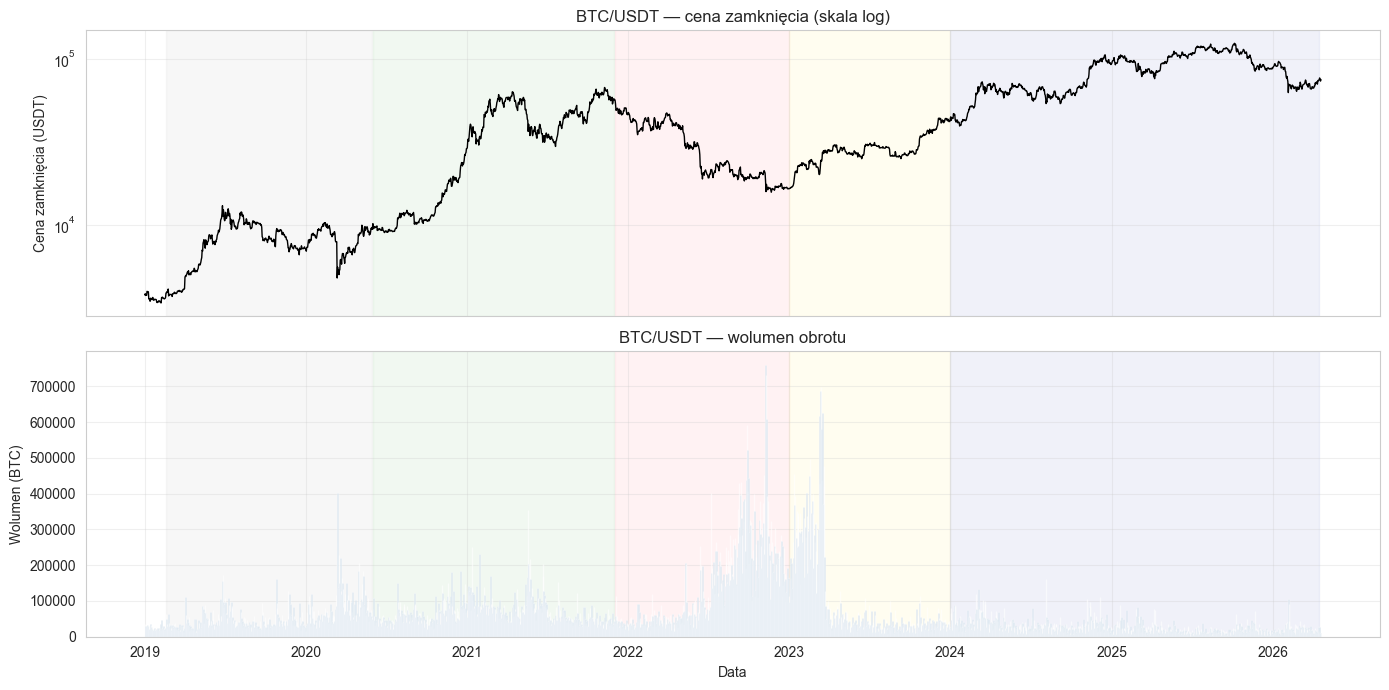

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(raw.index, raw["close"], color="black", linewidth=1)
axes[0].set_ylabel("Cena zamknięcia (USDT)")
axes[0].set_title("BTC/USDT — cena zamknięcia (skala log)")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

axes[1].bar(raw.index, raw["volume"], color="steelblue", width=1.0, alpha=0.6)
axes[1].set_ylabel("Wolumen (BTC)")
axes[1].set_xlabel("Data")
axes[1].set_title("BTC/USDT — wolumen obrotu")
axes[1].grid(True, alpha=0.3)

# Kolorowe tła per reżim — wizualizacja naszego podziału
regimes_palette = {
    "pre_2020":        "#e0e0e0",
    "bull_2020_2021":  "#c8e6c9",
    "bear_2022":       "#ffcdd2",
    "recovery_2023":   "#fff9c4",
    "bull_2024_plus":  "#c5cae9",
}
for regime_name, color in regimes_palette.items():
    regime_mask = features["regime"] == regime_name
    if regime_mask.any():
        regime_dates = features.index[regime_mask]
        for ax in axes:
            ax.axvspan(regime_dates.min(), regime_dates.max(), color=color, alpha=0.25, zorder=0)

plt.tight_layout()
plt.show()

## 3. Rozkład klas w targecie

Target jest lekko niezbalansowany (~54% klas pozytywnych = BTC ogólnie rośnie w długim terminie). Sprawdzamy też czy rozkład jest stabilny w czasie.

In [18]:
print("Rozkład klas:")
print(features["y"].value_counts(normalize=True).rename({0: "down (y=0)", 1: "up (y=1)"}))

print("\nRozkład klas per reżim:")
regime_target = features.groupby("regime")["y"].agg(["mean", "count"])
regime_target.columns = ["positive_rate", "n_samples"]
regime_target = regime_target.sort_values("positive_rate", ascending=False)
regime_target

Rozkład klas:
y
up (y=1)      0.539992
down (y=0)    0.460008
Name: proportion, dtype: float64

Rozkład klas per reżim:


,positive_rate,n_samples
regime,,
bull_2020_2021,0.587591,548
pre_2020,0.568376,468
recovery_2023,0.545205,365
bull_2024_plus,0.529904,836
bear_2022,0.457071,396


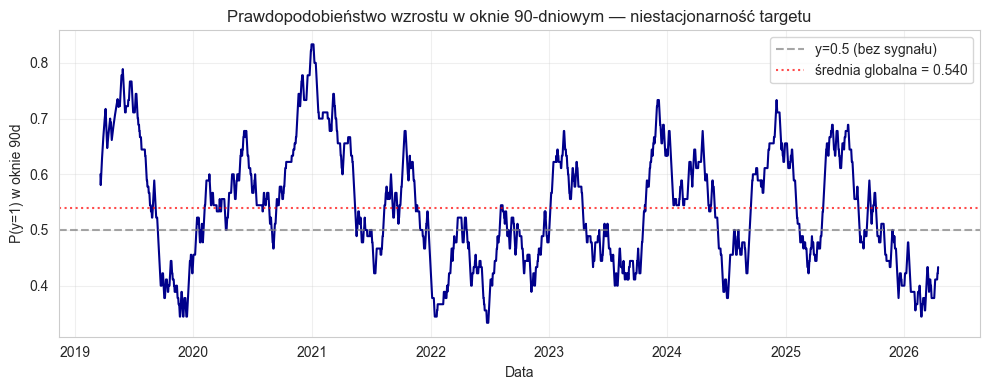

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))

# Rolling mean targetu — pokazuje jak zmienia się prawdopodobieństwo wzrostu w czasie
rolling_target = features["y"].rolling(window=90, min_periods=30).mean()
ax.plot(rolling_target.index, rolling_target, color="darkblue", linewidth=1.5)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.7, label="y=0.5 (bez sygnału)")
ax.axhline(features["y"].mean(), color="red", linestyle=":", alpha=0.7,
           label=f"średnia globalna = {features['y'].mean():.3f}")
ax.set_ylabel("P(y=1) w oknie 90d")
ax.set_xlabel("Data")
ax.set_title("Prawdopodobieństwo wzrostu w oknie 90-dniowym — niestacjonarność targetu")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Obserwacja:** target **nie jest stacjonarny** — w niektórych okresach prawdopodobieństwo wzrostu spada do ~0.3, w innych przekracza 0.7. To potwierdza wybór walk-forward validation zamiast zwykłego train-test split (Jansen, rozdz. 6, str. 170).

## 4. Rozkłady cech

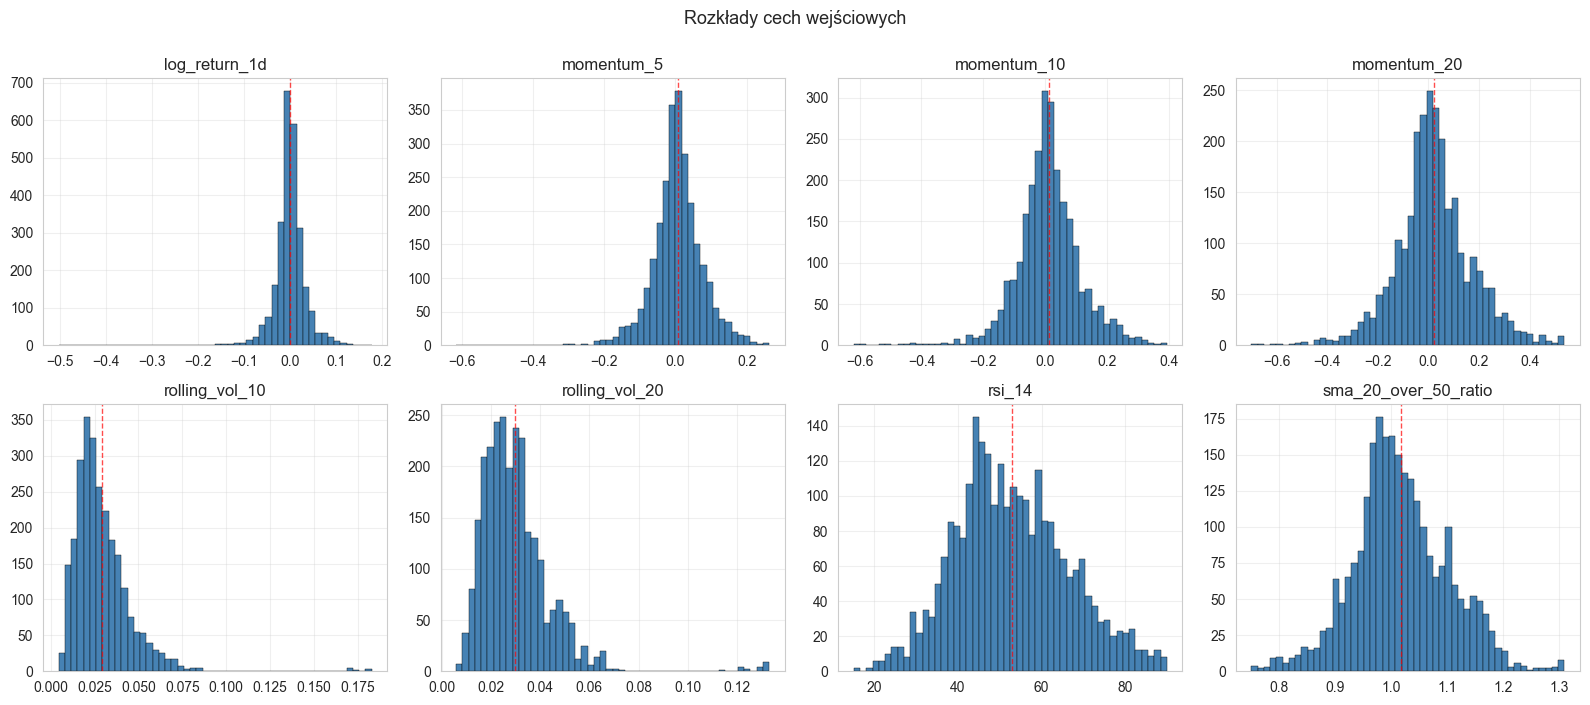

,log_return_1d,momentum_5,momentum_10,momentum_20,rolling_vol_10,rolling_vol_20,rsi_14,sma_20_over_50_ratio
count,2613.0000,2613.0000,2613.0000,2613.0000,2613.0000,2613.0000,2613.0000,2613.0000
mean,0.0011,0.0057,0.0114,0.0228,0.0291,0.0300,52.8987,1.0176
std,0.0333,0.0724,0.1037,0.1510,0.0164,0.0145,13.5301,0.0849
min,-0.5026,-0.6159,-0.6191,-0.7011,0.0045,0.0059,15.0444,0.7512
25%,-0.0132,-0.0297,-0.0428,-0.0549,0.0188,0.0207,43.5600,0.9665
50%,0.0005,0.0046,0.0085,0.0144,0.0257,0.0275,51.6919,1.0103
75%,0.0153,0.0434,0.0651,0.1030,0.0362,0.0359,61.9566,1.0704
max,0.1784,0.2633,0.3933,0.5379,0.1831,0.1331,89.9936,1.3092


In [20]:
feature_cols = [
    "log_return_1d", "momentum_5", "momentum_10", "momentum_20",
    "rolling_vol_10", "rolling_vol_20", "rsi_14",
    "sma_20_over_50_ratio",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), feature_cols):
    ax.hist(features[col], bins=50, color="steelblue", edgecolor="black", linewidth=0.3)
    ax.set_title(col)
    ax.grid(True, alpha=0.3)
    mean_val = features[col].mean()
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1, alpha=0.7)

plt.suptitle("Rozkłady cech wejściowych", y=1.00, fontsize=13)
plt.tight_layout()
plt.show()

features[feature_cols].describe().round(4)

## 5. Korelacje między cechami

Wysokie korelacje między cechami z tej samej rodziny (np. momentum_5 vs momentum_10) to oczekiwane zjawisko. Regularyzacja L2 w regresji logistycznej radzi sobie z tym problemem, a modele drzewiaste są na niego naturalnie odporne.

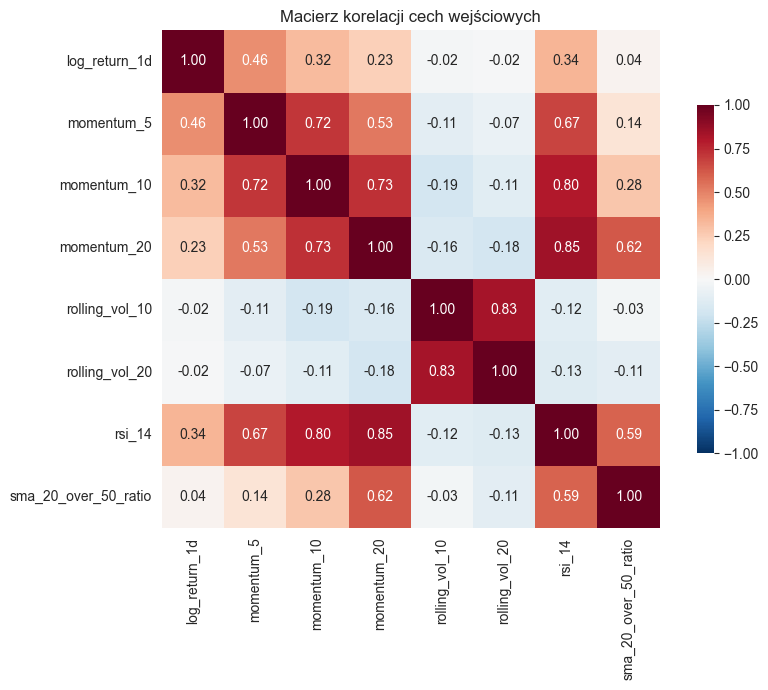

In [21]:
corr = features[feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={"shrink": 0.7})
ax.set_title("Macierz korelacji cech wejściowych")
plt.tight_layout()
plt.show()

## 6. Podsumowanie eksploracji

1. **Jakość danych:** 2613 użytecznych obserwacji po odrzuceniu okresu rozruchowego (rolling windows) i ostatnich 5 dni (future horizon). Brak braków danych, brak duplikatów w indeksie czasowym.
2. **Target:** ~54% klas pozytywnych - umiarkowane niezbalansowanie. **Niestacjonarność** targetu w czasie (waha się między 30% a 70% w oknach 90-dniowych) to główny argument za walk-forward validation.
3. **Cechy:** znaczące korelacje w ramach rodzin (momentum, volatility, SMA) - oczekiwane. Skale cech są różne (RSI 0-100, zwroty ~±0.1), więc dla regresji logistycznej wymagane jest skalowanie.
4. **Reżimy rynkowe:** pięć wyraźnie różnych faz (pre-2020, bull 2020-21, bear 2022, recovery 2023, bull 2024+) różniących się zarówno zmiennością jak i kierunkiem trendu. To daje materiał do analizy stabilności modeli per reżim (sekcja 3.9 pracy).